# LBT Fizeau PSF simulation

Generates three example images of the LBT Fizeau PSF with different combinations of tip, tilt, and phase error (OPD).

Observing wavelength: 3.7 um

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib inline

In [2]:
def lbt_aperture(delta_spacing, n_pix, d):
    '''
    Generate the two-aperture LBT pupil (SX (left) + DX (right)): 
    8.25 m diameter mirrors, with 14.4 m center-to-center separation

    INPUTS:
    delta_spacing (float): pixel size in the aperture image, in meters
    n_pix (int): number of pixels across the aperture
    d (float): diameter of the mirrors, in meters (usually 8.25)

    OUTPUTS:
    sx_aperture (array): boolean array of the SX aperture
    dx_aperture (array): boolean array of the DX aperture
    lbt_pupil (array): boolean array of the full LBT aperture
    xx (array): pupil x-coordinates in meters
    yy (array): pupil y-coordinates in meters
    '''

    # padding
    pad_factor = n_pix * delta_spacing / d

    # initialize meshgrid to set distances
    x_pos = np.arange(-d / 2.0 * pad_factor, d / 2.0 * pad_factor, delta_spacing)
    y_pos = np.arange(-d / 2.0 * pad_factor, d / 2.0 * pad_factor, delta_spacing)
    xx, yy = np.meshgrid(x_pos, y_pos)

    # set distances of the two subapertures
    xx_dx = xx - 7.2085
    xx_sx = xx + 7.2085

    # create boolean arrays that define the apertures
    r_sx = np.sqrt(xx_sx**2 + yy**2)
    r_dx = np.sqrt(xx_dx**2 + yy**2)
    sx_aperture = r_sx < d / 2.0
    dx_aperture = r_dx < d / 2.0
    lbt_pupil = sx_aperture + dx_aperture

    return sx_aperture, dx_aperture, lbt_pupil, xx, yy

In [3]:
def make_psf(sx_aperture, dx_aperture, piston_waves, wavel, tip_asec, tilt_asec, xx, yy):
    '''
    Complex focal-plane amplitude from the LBT pupil plus OPD and tip/tilt.

    INPUTS:
    sx_aperture (array): boolean array of the SX aperture
    dx_aperture (array): boolean array of the DX aperture
    piston_waves (float): DX piston in waves (OPD / wavelength)
    wavel (float): wavelength in meters
    tip_asec (float): tip in arcseconds (applied to DX only)
    tilt_asec (float): tilt in arcseconds (applied to DX only)
    xx (array): pupil x-coordinates in meters
    yy (array): pupil y-coordinates in meters

    OUTPUTS:
    focal_field (array): complex focal-plane amplitude
    pupil_field (array): complex pupil field
    '''

    # DX centroid (m); tip/tilt OPD is zero there so piston stays in piston_waves
    x_dx_cen = np.mean(xx[dx_aperture])
    y_dx_cen = np.mean(yy[dx_aperture])

    # wavefront tilt in radians (sky angle)
    tip_rad = tip_asec / 206265
    tilt_rad = tilt_asec / 206265

    # tip/tilt OPD in meters, then waves; SX is the phase reference
    opd_tip_tilt = (yy - y_dx_cen) * tip_rad + (xx - x_dx_cen) * tilt_rad
    tip_tilt_waves = opd_tip_tilt / wavel

    sx_field = np.multiply(1.0, sx_aperture)
    dx_field = np.multiply(
        dx_aperture, np.exp(1.j * 2 * np.pi * np.add(piston_waves, tip_tilt_waves))
    )

    # put the two subapertures together
    pupil_field = sx_field + dx_field

    # Fourier transform the pupil field to get the focal-plane amplitude
    focal_field = np.fft.fft2(pupil_field)
    focal_field = np.fft.fftshift(focal_field)

    return focal_field, pupil_field

In [4]:
def make_intensity(opd, tip_asec, tilt_asec, wavel=3.7e-6, n_pix=2048, d=8.25, ps_lmir=0.0107):
    '''
    Monochromatic intensity, as seen on the detector, for a given OPD (m) and differential tip/tilt (asec).

    INPUTS:
    opd (float): optical path difference in meters
    tip_asec (float): tip in arcseconds
    tilt_asec (float): tilt in arcseconds
    wavel (float): wavelength in meters (default: 3.7 um)
    n_pix (int): number of pixels across the aperture; this is not the detector itself,
        but rather an image of the aperture (default: 2048)
    d (float): diameter of the mirrors in meters (default: 8.25)
    ps_lmir (float): detector plate scale in arcsec/pixel (default: 0.0107)

    OUTPUTS:
    intensity (array): intensity in the detector plane
    pupil_phase (array): wrapped pupil phase in radians
    '''

    # pupil sampling that makes the FFT plate scale equal ps_lmir
    delta_spacing = (206265 / (n_pix * ps_lmir)) * wavel

    # get the apertures
    sx_aperture, dx_aperture, _, xx, yy = lbt_aperture(delta_spacing, n_pix, d)

    piston_waves = opd / wavel
    focal_field, pupil_field = make_psf(
        sx_aperture, dx_aperture, piston_waves, wavel, tip_asec, tilt_asec, xx, yy
    )

    # generate the intensity on detector
    intensity = np.real(focal_field * np.conj(focal_field))

    # wrapped pupil phase for plotting (masked outside the apertures)
    pupil_phase = np.angle(pupil_field)
    pupil_phase = np.ma.masked_where(np.abs(pupil_field) == 0, pupil_phase)

    return intensity, pupil_phase

In [5]:
def crop_center(img, half=80):
    '''
    Crop to the center of the image where the PSF is.

    INPUTS:
    img (array): image to crop
    half (int): half the size of the cropped image

    OUTPUTS:
    cropped_img (array): cropped image
    '''

    cy, cx = np.array(img.shape) // 2

    # crop the image
    return img[cy - half:cy + half, cx - half:cx + half]

In [6]:
# set wavelength 
wavel = 3.7e-6 # m

# set the plate scale of the detector
ps_lmir = 0.0107 # arcsec/pixel on detector

# number of pixels across the image of the aperture,
# as well as the number of pixels across the detector
n_pix = 2048

d = 8.25 # m

# examples of the LBT pupil (aka aperture); this function gets used by make_intensity()
delta_spacing = (206265 / (n_pix * ps_lmir)) * wavel # m / pupil pixel; spacing of the pixels
_, _, lbt_pupil, _, _ = lbt_aperture(delta_spacing, n_pix, d)



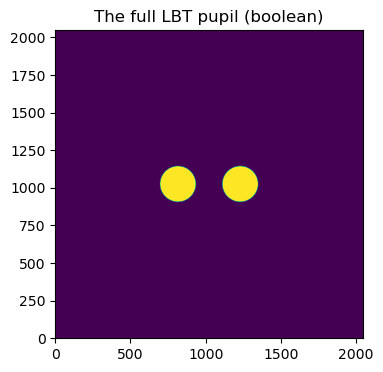

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes.imshow(lbt_pupil, origin="lower")
axes.set_title("The full LBT pupil (boolean)")
plt.show()

In [76]:
# three different cases of OPD, tip, and tilt
cases = [
    {"opd": 0.0, "tip": 0.0, "tilt": 0.0,
     "title": "Perfect\nOPD = 0, tip = 0, tilt = 0"},
    {"opd": 0.0, "tip": 0.07, "tilt": 0.07,
     "title": "Tip + tilt\nOPD = 0, tip = 0.07\", tilt = 0.07\""},
    {"opd": wavel / 5.00, "tip": 0.0, "tilt": 0.0,
     "title": "Phase error (λ/2)\nOPD = {:.2f} μm, tip = 0, tilt = 0".format(1e6 * wavel / 5.0)},
]

In [77]:
# generate the images for each case
psf_images = []
pupil_phase_images = []
for case in cases:
    intensity, pupil_phase = make_intensity(case["opd"], case["tip"], case["tilt"],
                       wavel=wavel, n_pix=n_pix, d=d, ps_lmir=ps_lmir)
    psf_images.append(crop_center(intensity))
    pupil_phase_images.append(pupil_phase)
    print("OPD = {:.2f} μm, tip = {} asec, tilt = {} asec".format(
        1e6 * case["opd"], case["tip"], case["tilt"]))

OPD = 0.00 μm, tip = 0.0 asec, tilt = 0.0 asec
OPD = 0.00 μm, tip = 0.07 asec, tilt = 0.07 asec
OPD = 0.74 μm, tip = 0.0 asec, tilt = 0.0 asec


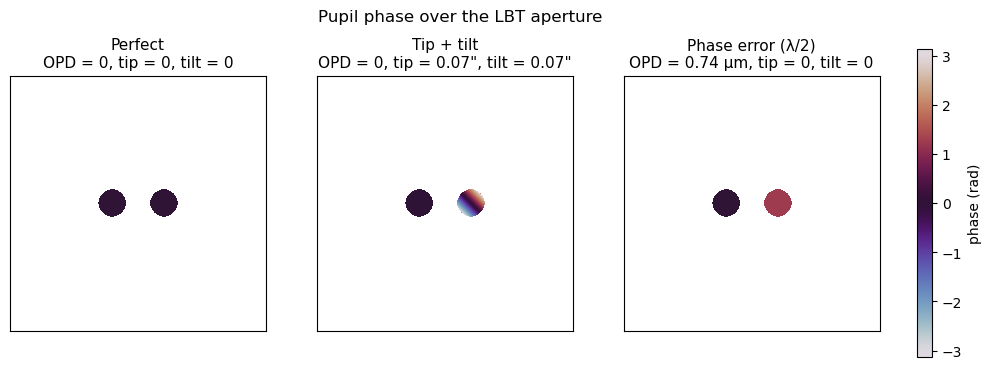

In [78]:
# make plots of the phase screens which carry the tip/tilt and OPD error

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
vmin, vmax = -np.pi, np.pi

for ax, im, case in zip(axes, pupil_phase_images, cases):
    pcm = ax.imshow(im, origin="lower", cmap="twilight", vmin=vmin, vmax=vmax)
    ax.set_title(case["title"], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(pcm, ax=axes.ravel().tolist(), fraction=0.025, pad=0.04, label="phase (rad)")
fig.suptitle("Pupil phase over the LBT aperture")
plt.show()

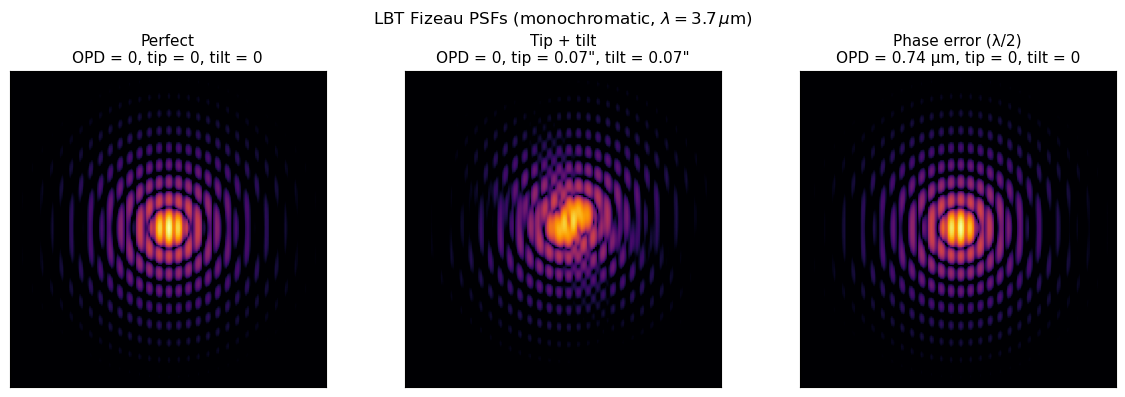

In [79]:
# make plots of PSFs with different OPD, tip, and tilt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
vmax = max(im.max() for im in psf_images)
vmin = max(vmax * 1e-4, min(im[im > 0].min() for im in psf_images))

for ax, im, case in zip(axes, psf_images, cases):
    ax.imshow(im, origin="lower", cmap="inferno", norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(case["title"], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("LBT Fizeau PSFs (monochromatic, $\\lambda = 3.7\\,\\mu$m)")
fig.tight_layout()
plt.show()